Load & Understand the Data

In [48]:
X = [50, 60, 70, 80, 90]
y = [150, 180, 210, 240, 270]


What do X and y represent?

X → House size (in m²)

y → House price (in thousands)

So the dataset shows that every 10 m² increase in size increases the price by 30 (thousand).

Convert to NumPy arrays

In [49]:
import numpy as np

X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

Create and Train the Model

1️-Create instance

In [50]:
import matplotlib.pyplot as plt
import numpy as np

class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.theta_0 = 0
        self.theta_1 = 0
        self.sse_history = []
    
    def fit(self, X, y):
        n = len(X)
        for _ in range(self.n_iters):
            y_pred = self.theta_0 + self.theta_1 * X
            error = y_pred - y
            
            # Gradient calculations
            d_theta_0 = (2/n) * np.sum(error)
            d_theta_1 = (2/n) * np.sum(error * X)
            
            # Update parameters
            self.theta_0 -= self.lr * d_theta_0
            self.theta_1 -= self.lr * d_theta_1
            
            # Save SSE for visualization [cite: 32]
            sse = np.sum(error**2)
            self.sse_history.append(sse)
    
    def predict(self, X):
        return self.theta_0 + self.theta_1 * X

   
    def plot_training(self, X, y):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
        # 1. Visualize SSE over iterations [cite: 32]
        ax1.plot(range(len(self.sse_history)), self.sse_history, color='blue')
        ax1.set_title('SSE over Iterations')
        ax1.set_xlabel('Iterations')
        ax1.set_ylabel('Sum of Squared Error (SSE)')
        
        # 2. Plot the regression line with data points [cite: 33]
        ax2.scatter(X, y, color='red', label='Actual Data')
        ax2.plot(X, self.predict(X), color='green', label='Regression Line')
        ax2.set_title('Regression Line')
        ax2.set_xlabel('House Size (X)')
        ax2.set_ylabel('Price (y)')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

In [51]:
X = np.array([50, 60, 70, 80, 90])
y = np.array([150, 180, 210, 240, 270])

model = LinearRegressionGD(learning_rate=0.00001, n_iters=1000)
model.fit(X, y)

print("theta_0:", model.theta_0)
print("theta_1:", model.theta_1)


theta_0: 0.04113676052353117
theta_1: 2.9994353734559427


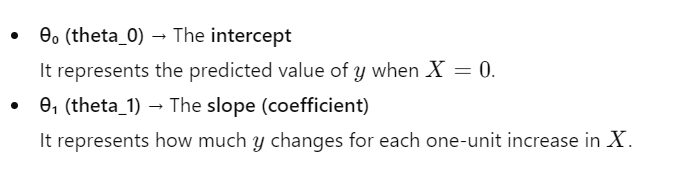

3) Prediction

In [52]:
prediction = model.predict(np.array([70]))
print("Predicted price:", prediction)


Predicted price: [210.0016129]


4-Visualization

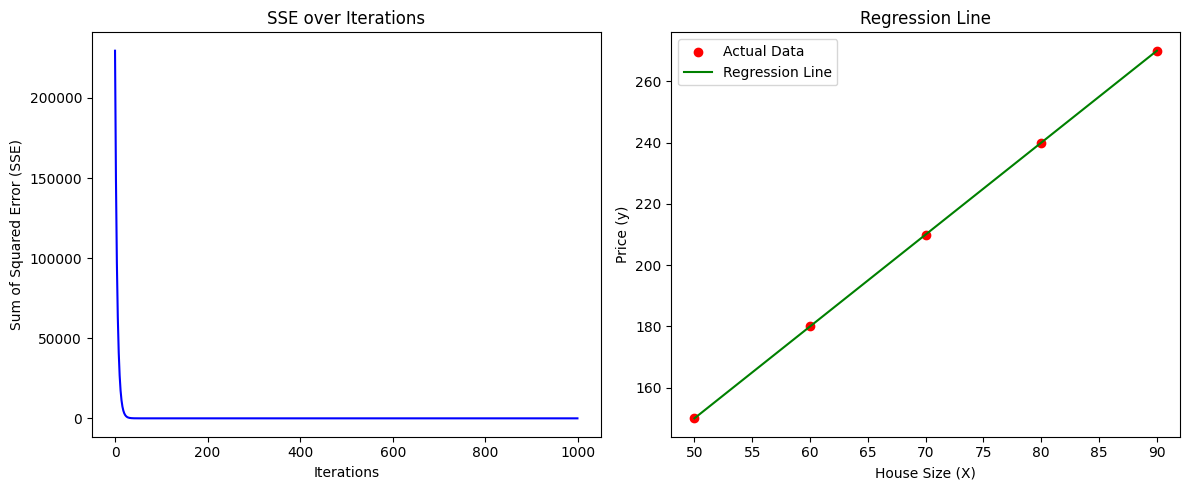

In [ ]:
model.plot_training(X, y)



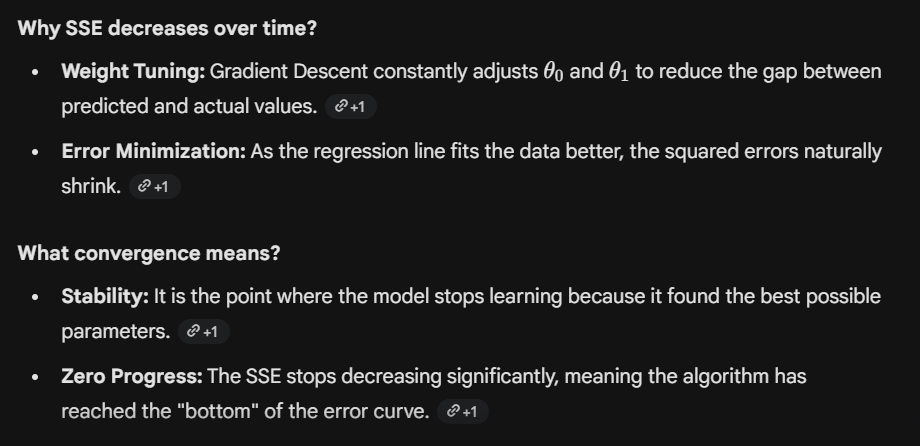

Experimentation

Small LR - Final SSE: 187504.31789687806
Large LR - Final SSE: inf


C:\Users\el_bostan\AppData\Local\Temp\ipykernel_26184\2712738250.py:27: RuntimeWarning: overflow encountered in square
  sse = np.sum(error**2)


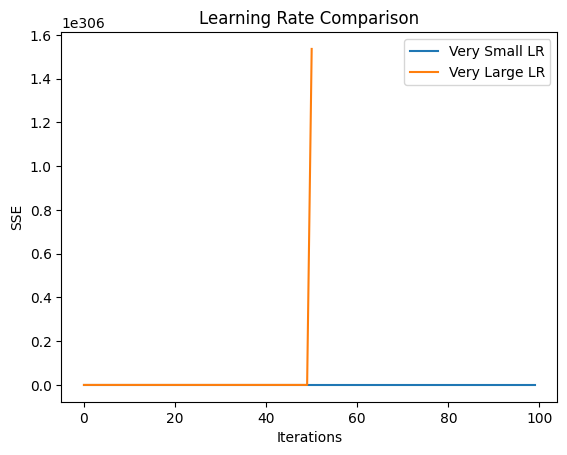

In [54]:

model_small = LinearRegressionGD(learning_rate=1e-7, n_iters=100) 
model_small.fit(X, y)
print(f"Small LR - Final SSE: {model_small.sse_history[-1]}") 


model_large = LinearRegressionGD(learning_rate=0.1, n_iters=100) 
model_large.fit(X, y)
print(f"Large LR - Final SSE: {model_large.sse_history[-1]}") 


plt.plot(model_small.sse_history, label='Very Small LR')
plt.plot(model_large.sse_history, label='Very Large LR')
plt.title('Learning Rate Comparison')
plt.xlabel('Iterations')
plt.ylabel('SSE')
plt.legend()
plt.show() 

Bonus Tasks 

In [55]:
class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, n_iters=100):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.theta = None 
        self.theta_0 = 0
        self.sse_history = []

  
    def fit(self, X, y):
        if X.ndim == 1: X = X.reshape(-1, 1) 
        n_samples, n_features = X.shape
        self.theta = np.zeros(n_features)
        
        for _ in range(self.n_iters):
            y_pred = self.theta_0 + np.dot(X, self.theta)
            error = y_pred - y
            
           
            d_theta_0 = (2/n_samples) * np.sum(error)
            d_theta = (2/n_samples) * np.dot(X.T, error)
            
     
            self.theta_0 -= self.lr * d_theta_0
            self.theta -= self.lr * d_theta
            
            self.sse_history.append(np.sum(error**2))

    def predict(self, X):
        if X.ndim == 1: X = X.reshape(-1, 1)
        return self.theta_0 + np.dot(X, self.theta)

  
    def calculate_mse(self, X, y):
        y_pred = self.predict(X)
        return np.mean((y - y_pred)**2)

In [56]:
# Normalize X: (X - mean) / std
X_mean = np.mean(X)
X_std = np.std(X)
X_normalized = (X - X_mean) / X_std


model_norm = LinearRegressionGD(learning_rate=0.1, n_iters=100)
model_norm.fit(X_normalized, y)

print(f"MSE after Normalization: {model_norm.calculate_mse(X_normalized, y)}")

MSE after Normalization: 1.904628876626759e-15
